# Compare Cell Statistics: SCREAM vs GridRad

This notebook compares convective cell statistics between SCREAM and GridRad datasets over CONUS.

**Datasets:**
- GridRad: `/pscratch/sd/i/iclas2/GridRad/cell_conus_nofilter/stats/cell_stats_20200401_20200831.parquet`
- SCREAM: `/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/stats/cell_stats_20200401_20200831.parquet`

**Analysis:**
1. Count number of cells per month on a gridded domain
2. Visualize and compare spatial distributions

In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from pathlib import Path
from scipy.ndimage import gaussian_filter
import seaborn as sns
from sklearn.neighbors import KernelDensity
from scipy.stats import pearsonr, spearmanr, linregress
import copy
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# Optional: colormaps for better visualization
try:
    import colormaps as colormaps
except ImportError:
    print("Warning: colormaps not found. Using default colormaps.")
    colormaps = None

## Configuration

In [56]:
name_map = {'s1': 'SCREAM', 's2': 'GridRad'}

# File paths
file_s1 = '/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/stats/cell_stats_20200401_20200831.parquet'
file_s2 = '/pscratch/sd/i/iclas2/GridRad/cell_conus_nofilter/stats/cell_stats_20200401_20200831.parquet'

# Grid resolution (degrees)
grid_res_x = 1.0  # longitude
grid_res_y = 1.0  # latitude

# Map extent for CONUS [lon_min, lon_max, lat_min, lat_max]
map_extent = [235, 295, 25, 50]

# Map resolution
map_resolution = '50m'

# terrain_file = '/pscratch/sd/w/wcmca1/SCREAMv1-cess2/maps/hrrr_sfc_latlon_orog_lsm.nc'
terrain_file = '/global/cfs/cdirs/m2637/zfeng/FACETS/narr/map_data/hgt.sfc.nc'

figdir = '/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/'
os.makedirs(figdir, exist_ok=True)

# Figure settings
dpi = 240
fontsize = 10

## Load terrain data

In [ ]:
# Read topography and land fraction data
dstop = xr.open_dataset(terrain_file).squeeze().isel(x=slice(100,300), y=slice(40,200))  # Subset to CONUS region
ter = dstop.hgt
ter_s = gaussian_filter(ter, 0.6)
lon_ter = dstop.lon.load()
lat_ter = dstop.lat.load()
dstop

fig = plt.figure(figsize=[10,5], dpi=100)
plt.pcolormesh(lon_ter, lat_ter, ter_s, cmap='terrain')
plt.colorbar()

In [ ]:
# # Read topography and land fraction data
# dstop = xr.open_dataset(terrain_file)
# ter = dstop.orog
# landfrac = dstop.lsm
# ter_s = gaussian_filter(ter, 3)
# lon_ter = dstop.longitude.load()
# lat_ter = dstop.latitude.load()
# dstop

## Load Data

In [ ]:
# Load s1 statistics
print(f"Loading {name_map['s1']} data...")
df_s1 = pd.read_parquet(file_s1)
print(f"{name_map['s1']}: {len(df_s1)} cells")
print(f"Columns: {df_s1.columns.tolist()}")
display(df_s1.head())

In [ ]:
# Load s2 statistics
print(f"Loading {name_map['s2']} data...")
df_s2 = pd.read_parquet(file_s2)
print(f"{name_map['s2']}: {len(df_s2)} cells")
print(f"Columns: {df_s2.columns.tolist()}")
display(df_s2.head())

## Function: Count Cells on Grid by Month

In [ ]:
def count_cells_monthly_grid(df, lon_col='meanlat', lat_col='meanlon', 
                             time_col='base_time',
                             grid_res_x=1.0, grid_res_y=1.0, 
                             lon_range=None, lat_range=None):
    """
    Count number of cells per month on a regular lat/lon grid.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Cell statistics dataframe containing cell center coordinates and time
    lon_col : str
        Column name for longitude (cell center)
    lat_col : str
        Column name for latitude (cell center)
    time_col : str
        Column name for time variable
    grid_res_x : float
        Grid resolution in longitude (degrees)
    grid_res_y : float
        Grid resolution in latitude (degrees)
    lon_range : tuple, optional
        Longitude range (min, max). If None, uses data extent.
    lat_range : tuple, optional
        Latitude range (min, max). If None, uses data extent.
    
    Returns:
    --------
    cell_counts : xr.DataArray
        Array with dimensions [month, lat, lon] containing cell counts
    """
    
    # Make a copy and ensure time column is datetime
    df_work = df.copy()
    
    # Convert time to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(df_work[time_col]):
        # Assume Unix timestamp if numeric
        df_work[time_col] = pd.to_datetime(df_work[time_col], unit='s')
    
    # Extract month
    df_work['month'] = df_work[time_col].dt.month
    
    # Determine lon/lat ranges
    if lon_range is None:
        lon_min = df_work[lon_col].min()
        lon_max = df_work[lon_col].max()
    else:
        lon_min, lon_max = lon_range
    
    if lat_range is None:
        lat_min = df_work[lat_col].min()
        lat_max = df_work[lat_col].max()
    else:
        lat_min, lat_max = lat_range
    
    # Create grid edges
    lon_edges = np.arange(lon_min, lon_max + grid_res_x, grid_res_x)
    lat_edges = np.arange(lat_min, lat_max + grid_res_y, grid_res_y)
    
    # Grid centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    
    # Get unique months
    months = sorted(df_work['month'].unique())
    
    # Initialize counts array [month, lat, lon]
    cell_counts = np.zeros((len(months), len(lat_centers), len(lon_centers)))
    
    # Loop through months and count cells in each grid box
    for im, month in enumerate(months):
        df_month = df_work[df_work['month'] == month]
        
        # Bin cells into grid boxes
        counts, _, _ = np.histogram2d(
            df_month[lat_col], 
            df_month[lon_col],
            bins=[lat_edges, lon_edges]
        )
        
        cell_counts[im, :, :] = counts
    
    # Create xarray DataArray with coordinates
    cell_counts_da = xr.DataArray(
        cell_counts,
        coords={
            'month': months,
            'latitude': lat_centers,
            'longitude': lon_centers
        },
        dims=['month', 'latitude', 'longitude'],
        attrs={'long_name': 'Cell count', 'units': 'count'}
    )
    
    return cell_counts_da

## Count Cells on Grid

In [ ]:
# Define grid domain based on map extent
lon_range = (map_extent[0], map_extent[1])
lat_range = (map_extent[2], map_extent[3])

# Count GridRad cells
print("Counting GridRad cells on grid...")
counts_s2 = count_cells_monthly_grid(
    df_s2, 
    lon_col='center_lon',  # Adjust based on actual column names
    lat_col='center_lat',  # Adjust based on actual column names
    time_col='time',
    grid_res_x=grid_res_x,
    grid_res_y=grid_res_y,
    lon_range=lon_range,
    lat_range=lat_range
)
print(f"GridRad counts shape: {counts_s2.shape}")
print(f"Months: {counts_s2.month.values}")

In [ ]:
# Count SCREAM cells
print("Counting SCREAM cells on grid...")
counts_s1 = count_cells_monthly_grid(
    df_s1, 
    lon_col='center_lon',  # Adjust based on actual column names
    lat_col='center_lat',  # Adjust based on actual column names
    time_col='time',
    grid_res_x=grid_res_x,
    grid_res_y=grid_res_y,
    lon_range=lon_range,
    lat_range=lat_range
)
print(f"SCREAM counts shape: {counts_s1.shape}")
print(f"Months: {counts_s1.month.values}")

In [ ]:
counts_s1.sel(month=6).plot()

In [ ]:
counts_s2.sel(month=6).plot()

## Function: Plot Cell Counts (Multi-panel Lambert)

In [ ]:
def plot_mxn_panels_lambert(nrow, ncol, data_arrays, lon_1d, lat_1d, cmaps, levels, 
                             titles=None, cbar_labels=None, figsize=(15, 10), 
                             dpi=150, map_extent=None, suptitle=None,
                             wspace=0.15, hspace=0.25, fontsize=12, show_terrain=False,
                             map_resolution='50m', cbar_mode='each', cbar_ticks=None, figname=None):
    """
    Create a m×n panel plot with LambertConformal projection for gridded data.
    
    Parameters:
    -----------
    nrow : int
        Number of rows
    ncol : int
        Number of columns
    data_arrays : list of lists (nrow × ncol)
        Nested list containing 2D data arrays to plot. Can contain None for empty panels.
    lon_1d : 1D array
        Longitude coordinates (centers)
    lat_1d : 1D array
        Latitude coordinates (centers)
    cmaps : list of lists (nrow × ncol)
        Nested list of colormap names for each panel
    levels : list of lists (nrow × ncol)
        Nested list of (vmin, vmax) tuples for each panel
    titles : list of lists (nrow × ncol), optional
        Nested list of titles for each panel
    cbar_labels : list of lists (nrow × ncol), optional
        Nested list of colorbar labels for each panel
    figsize : tuple, optional
        Figure size (width, height)
    dpi : int, optional
        Figure resolution
    map_extent : tuple, optional
        Map extent as (lon_min, lon_max, lat_min, lat_max)
    suptitle : string, optional
        Suptitle for figure
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    fontsize : int, optional
        Base font size for labels
    show_terrain : bool, optional
        Whether to overlay terrain contours (requires global variables lon_ter, lat_ter, ter_s)
    map_resolution : str, optional
        Map resolution: '10m', '50m', or '110m'
    cbar_mode : str, optional
        Colorbar mode: 'each' (one per panel), 'row' (one per row), 'figure' (one for entire figure)
    cbar_ticks : list of lists (nrow × ncol) or None, optional
        Nested list of tick values for colorbars. If None, uses default ticks.
    figname : string, optional
        Name of the figure to save.
    
    Returns:
    --------
    fig : matplotlib figure
    axes : list of lists (nrow × ncol) of axes
    """
    
    mpl.rcParams['font.size'] = fontsize
    
    # Set default map extent
    if map_extent is None:
        map_extent = [lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()]
    
    # Calculate central longitude for projection
    central_lon = (map_extent[0] + map_extent[1]) / 2
    
    # Create projection
    proj = ccrs.LambertConformal(central_longitude=central_lon)
    
    # Map features
    land = cfeature.NaturalEarthFeature('physical', 'land', map_resolution)
    borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', map_resolution)
    states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', map_resolution)
    map_edgecolor = 'k'
    
    # Set default titles and labels if not provided
    if titles is None:
        titles = [[f'Panel {i*ncol + j + 1}' for j in range(ncol)] for i in range(nrow)]
    if cbar_labels is None:
        cbar_labels = [['' for j in range(ncol)] for i in range(nrow)]
    
    # Create figure
    fig = plt.figure(figsize=figsize, dpi=dpi)
    
    # Adjust GridSpec based on colorbar mode
    if cbar_mode == 'figure':
        # Create outer GridSpec with space for figure-wide colorbar
        gs_outer = gridspec.GridSpec(1, 2, figure=fig, 
                                    width_ratios=[1, 0.03], 
                                    wspace=0.05)
        gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_outer[0],
                                              height_ratios=list(np.repeat(1, nrow)),
                                              width_ratios=list(np.repeat(1, ncol)),
                                              wspace=wspace, hspace=hspace)
    elif cbar_mode == 'row':
        # Create GridSpec with extra column for row colorbars
        gs = gridspec.GridSpec(nrow, ncol + 1, figure=fig,
                              height_ratios=list(np.repeat(1, nrow)),
                              width_ratios=list(np.repeat(1, ncol)) + [0.03],
                              wspace=wspace, hspace=hspace)
    else:  # cbar_mode == 'each'
        # Standard GridSpec
        gs = gridspec.GridSpec(nrow, ncol, figure=fig, 
                              height_ratios=list(np.repeat(1, nrow)),
                              width_ratios=list(np.repeat(1, ncol)),
                              wspace=wspace, hspace=hspace)
    
    # Create axes for each panel
    axes = [[None for j in range(ncol)] for i in range(nrow)]
    
    # Store image artists for colorbars
    row_ims = [[] for _ in range(nrow)]  # For row colorbars
    all_ims = []  # For figure colorbar
    
    # Create meshgrid for pcolormesh (edges)
    dlon = lon_1d[1] - lon_1d[0] if len(lon_1d) > 1 else 1.0
    dlat = lat_1d[1] - lat_1d[0] if len(lat_1d) > 1 else 1.0
    lon_edges = np.concatenate([lon_1d - dlon/2, [lon_1d[-1] + dlon/2]])
    lat_edges = np.concatenate([lat_1d - dlat/2, [lat_1d[-1] + dlat/2]])
    lon_2d, lat_2d = np.meshgrid(lon_edges, lat_edges)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if data is provided for this panel
            if data_arrays[row][col] is not None:
                if cbar_mode == 'each':
                    # Setup two columns (left: plot, right: colorbar)
                    gss = gridspec.GridSpecFromSubplotSpec(
                        1, 2, subplot_spec=gs[row, col], 
                        height_ratios=[1], width_ratios=[1, 0.04], 
                        wspace=0.02, hspace=0.
                    )
                    ax = plt.subplot(gss[0], projection=proj)
                    cax = plt.subplot(gss[1])
                else:
                    # Just create axis for the plot
                    ax = plt.subplot(gs[row, col], projection=proj)
                
                # Set extent
                ax.set_extent(map_extent, crs=ccrs.PlateCarree())
                
                # Add map features
                ax.add_feature(states, edgecolor='gray', facecolor='none', linewidth=0.5, zorder=3)
                ax.add_feature(borders, edgecolor=map_edgecolor, facecolor='none', linewidth=0.5, zorder=3)
                ax.add_feature(land, facecolor='none', edgecolor=map_edgecolor, linewidth=0.5, zorder=3)
                ax.set_aspect('auto', adjustable=None)                
                
                # Create color normalization (same for all columns in this row)
                cmap = plt.get_cmap(cmaps[row][col])
                norm = mpl.colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                # Plot data
                # vmin, vmax = levels[row][col]
                im = ax.pcolormesh(lon_2d, lat_2d, data_arrays[row][col], 
                                  transform=ccrs.PlateCarree(),
                                  cmap=cmaps[row][col], norm=norm,
                                  shading='auto')
                
                # Overplot terrain contours
                if show_terrain:
                    ter_levels = [500, 1000, 2000]
                    CS = ax.contour(lon_ter, lat_ter, ter_s, levels=ter_levels, colors='dimgray', linewidths=0.7, transform=ccrs.PlateCarree(), zorder=4)
                    ax.clabel(CS, inline=True, fontsize=fontsize*0.5, fmt='%.0f')
                
                # Add title
                ax.set_title(titles[row][col], loc='left', fontsize=fontsize, fontweight='bold')
                
                # Add gridlines
                gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', 
                                 alpha=0.5, linestyle='--')
                gl.right_labels = False
                gl.top_labels = False
                
                # Add axis labels only on outer edges
                if row == nrow - 1:  # Bottom row
                    ax.set_xlabel('Longitude', fontsize=fontsize-2)
                if col == 0:  # Left column
                    ax.set_ylabel('Latitude', fontsize=fontsize-2)
                
                # Handle colorbar based on mode
                if cbar_mode == 'each':
                    # Create colorbar for this panel
                    cbar = plt.colorbar(im, cax=cax, label=cbar_labels[row][col])
                    if cbar_ticks is not None and cbar_ticks[row][col] is not None:
                        cbar.set_ticks(cbar_ticks[row][col])
                elif cbar_mode == 'row':
                    # Store image for row colorbar
                    row_ims[row].append(im)
                else:  # cbar_mode == 'figure'
                    # Store image for figure colorbar
                    all_ims.append(im)
                
                axes[row][col] = ax
    
    # Create row colorbars if needed
    if cbar_mode == 'row':
        for row in range(nrow):
            if row_ims[row]:  # If there are images in this row
                # Create colorbar axis for this row
                cax = plt.subplot(gs[row, ncol])
                # Use the first image for colorbar (assumes all in row have same scale)
                im = row_ims[row][0]
                # Get label from first non-empty panel in row
                label = ''
                for col in range(ncol):
                    if data_arrays[row][col] is not None and cbar_labels[row][col]:
                        label = cbar_labels[row][col]
                cbar = plt.colorbar(im, cax=cax, label=label)
                # Set custom ticks if provided
                if cbar_ticks is not None and cbar_ticks[row][0] is not None:
                    cbar.set_ticks(cbar_ticks[row][0])
    
    # Create figure-wide colorbar if needed
    if cbar_mode == 'figure' and all_ims:
        cax = plt.subplot(gs_outer[1])
        # Use the first image for colorbar (assumes all have same scale)
        ticks = None
        for row in range(nrow):
            for col in range(ncol):
                if data_arrays[row][col] is not None and cbar_labels[row][col]:
                    label = cbar_labels[row][col]
                    if cbar_ticks is not None and cbar_ticks[row][col] is not None:
                        ticks = cbar_ticks[row][col]
                    break
            if label:
                break
        cbar = plt.colorbar(im, cax=cax, label=label)
        if ticks is not None:
            cbar.set_ticks(ticks)
    
    # Figure title
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize*1.2, fontweight='bold', y=0.98)

    # Save figure if filename provided
    if figname is not None:
        print(f"Saved: {figname}")
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        
    return fig, axes

**Colorbar Options:**
- `cbar_mode='each'`: One colorbar next to each panel (default)
- `cbar_mode='row'`: One colorbar per row on the right side
- `cbar_mode='figure'`: One colorbar for the entire figure on the right side
- `cbar_ticks`: Optional nested list of tick values for custom colorbar ticks

## Plot Monthly Cell Counts: GridRad vs SCREAM

In [ ]:
# Get month names for titles
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

# Get available months
months = counts_s2.month.values
n_months = len(months)

# Layout: 3 rows x 5 columns
# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
# Row 2: GridRad - Apr, May, Jun, Jul, Aug
# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
nrow = 3
ncol = 5

# map_extent_plt = [-110, -75, 25, 49]
map_extent_plt = [-120, -75, 25, 49]

# Prepare data arrays as nested list [row][col]
data_arrays = []
titles = []
cmaps = []
levels = []
cbar_labels = []

# Determine common color scale for SCREAM and GridRad
vmin_count = 0
vmax_count = 600
# vmax_count = max(float(counts_s2.max()), float(counts_s1.max()))

# Calculate difference for color scale
diff_counts = counts_s1 - counts_s2
min_count = 0
diff_counts = diff_counts.where(counts_s2 > min_count, 0)  # mask out where s2 is zero

# Choose colormaps
if colormaps is not None:
    cmap_count = colormaps.WhiteBlueGreenYellowRed
    # cmap_count = colormaps.wh_bl_gr_ye_re
    cmap_diff = 'RdBu_r'
else:
    cmap_count = 'YlOrRd'
    cmap_diff = 'RdBu_r'

# Specify color levels
row_lev1 = np.arange(0, vmax_count+1, 50)
row_lev2 = row_lev1
# row_lev3 = np.arange(vmin_diff, vmax_diff+1, 200)
row_lev3 = [-1000,-800,-600,-400,-300,-200,-100,100,200,300,400,600,800,1000]
# row_lev3 = [-300,-200,-150,-100,-50,-25,25,50,100,150,200,300]
levels = [
    [row_lev1]*ncol,
    [row_lev2]*ncol,
    [row_lev3]*ncol,
]
row_cbar_ticks1 = np.arange(0, vmax_count+1, 100)
row_cbar_ticks2 = row_cbar_ticks1
row_cbar_ticks3 = row_lev3
cbar_ticks = [
    [row_cbar_ticks1]*ncol,
    [row_cbar_ticks2]*ncol,
    [row_cbar_ticks3]*ncol,
]

# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s1.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
cbar_labels.append(row_cbar_labels)

# Row 2: GridRad - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s2.sel(month=month).values)
    row_titles.append(f"{name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
cbar_labels.append(row_cbar_labels)

# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
# row_levels = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(diff_counts.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} - {name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_diff)
    # row_levels.append((vmin_diff, vmax_diff))
    row_cbar_labels.append(f'$\\Delta$Cell Count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
# levels.append(row_levels)
cbar_labels.append(row_cbar_labels)

# Adjust figure size based on layout (3 rows x 5 columns)
fig_width = 4 * ncol
fig_height = 3 * nrow
print(f"Figure size: {fig_width} x {fig_height} inches")

fontsize = 10
figname = f'{figdir}Maps_MonthlyCellCount_{name_map["s1"]}_{name_map["s2"]}_Diff_{grid_res_x}x{grid_res_y}.png'

# Create the plot with one colorbar per row
fig, axes = plot_mxn_panels_lambert(
    nrow=nrow, ncol=ncol,
    data_arrays=data_arrays,
    lon_1d=counts_s2.longitude.values,
    lat_1d=counts_s2.latitude.values,
    cmaps=cmaps,
    levels=levels,
    titles=titles,
    cbar_labels=cbar_labels,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    map_extent=map_extent_plt,
    suptitle=f"Monthly Cell Counts (Apr-Aug 2020) | Grid: {grid_res_x}°×{grid_res_y}°",
    wspace=0.05,
    hspace=0.25,
    fontsize=fontsize,
    show_terrain=True,
    map_resolution=map_resolution,
    cbar_mode='row',  # One colorbar per row
    cbar_ticks=cbar_ticks,  # Custom tick values for colorbars
    figname=figname
)


In [ ]:
# Get month names for titles
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

# Get available months
months = counts_s2.month.values
n_months = len(months)

# Layout: 3 rows x 5 columns
# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
# Row 2: GridRad - Apr, May, Jun, Jul, Aug
# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
nrow = 3
ncol = 5

# map_extent_plt = [-110, -75, 25, 49]
map_extent_plt = [-120, -75, 25, 49]

# Prepare data arrays as nested list [row][col]
data_arrays = []
titles = []
cmaps = []
levels = []
cbar_labels = []

# Determine common color scale for SCREAM and GridRad
vmin_count = 0
vmax_count = 600
# vmax_count = max(float(counts_s2.max()), float(counts_s1.max()))

# Calculate percentage difference
diff_counts = 100 * (counts_s1 - counts_s2) / counts_s2  
min_count = 50
diff_counts = diff_counts.where(counts_s2 > min_count, 0)  # mask out where s2 is too low to avoid large percentage differences

# Choose colormaps
if colormaps is not None:
    cmap_count = colormaps.WhiteBlueGreenYellowRed
    # cmap_count = colormaps.wh_bl_gr_ye_re
    cmap_diff = 'RdBu_r'
else:
    cmap_count = 'YlOrRd'
    cmap_diff = 'RdBu_r'

# Specify color levels
row_lev1 = np.arange(0, vmax_count+1, 50)
row_lev2 = row_lev1
# row_lev3 = np.arange(vmin_diff, vmax_diff+1, 200)
# row_lev3 = [-100,-80,-60,-40,-30,-20,-10,10,20,30,40,60,80,100]
row_lev3 = [-400,-300,-200,-150,-100,-50,-25,25,50,100,150,200,300,400]
levels = [
    [row_lev1]*ncol,
    [row_lev2]*ncol,
    [row_lev3]*ncol,
]
row_cbar_ticks1 = np.arange(0, vmax_count+1, 100)
row_cbar_ticks2 = row_cbar_ticks1
row_cbar_ticks3 = row_lev3
cbar_ticks = [
    [row_cbar_ticks1]*ncol,
    [row_cbar_ticks2]*ncol,
    [row_cbar_ticks3]*ncol,
]

# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s1.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
cbar_labels.append(row_cbar_labels)

# Row 2: GridRad - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s2.sel(month=month).values)
    row_titles.append(f"{name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
cbar_labels.append(row_cbar_labels)

# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
# row_levels = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(diff_counts.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} - {name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_diff)
    # row_levels.append((vmin_diff, vmax_diff))
    row_cbar_labels.append(f'$\\Delta$Cell Count (%)')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
# levels.append(row_levels)
cbar_labels.append(row_cbar_labels)

# Adjust figure size based on layout (3 rows x 5 columns)
fig_width = 4 * ncol
fig_height = 3 * nrow
print(f"Figure size: {fig_width} x {fig_height} inches")

fontsize = 10
figname = f'{figdir}Maps_MonthlyCellCount_{name_map["s1"]}_{name_map["s2"]}_PercentDiff_{grid_res_x}x{grid_res_y}.png'

# Create the plot with one colorbar per row
fig, axes = plot_mxn_panels_lambert(
    nrow=nrow, ncol=ncol,
    data_arrays=data_arrays,
    lon_1d=counts_s2.longitude.values,
    lat_1d=counts_s2.latitude.values,
    cmaps=cmaps,
    levels=levels,
    titles=titles,
    cbar_labels=cbar_labels,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    map_extent=map_extent_plt,
    suptitle=f"Monthly Cell Counts (Apr-Aug 2020) | Grid: {grid_res_x}°×{grid_res_y}°",
    wspace=0.05,
    hspace=0.25,
    fontsize=fontsize,
    show_terrain=True,
    map_resolution=map_resolution,
    cbar_mode='row',  # One colorbar per row
    cbar_ticks=cbar_ticks,  # Custom tick values for colorbars
    figname=figname
)


## Summary Statistics

In [ ]:
# Calculate summary statistics
print("\n=== Summary Statistics ===")
print(f"\nGridRad:")
print(f"  Total cells (all months): {counts_s2.sum().values:,.0f}")
print(f"  Mean cells per grid box: {float(counts_s2.mean()):.1f}")
print(f"  Max cells per grid box: {float(counts_s2.max()):.0f}")

print(f"\nSCREAM:")
print(f"  Total cells (all months): {counts_s1.sum().values:,.0f}")
print(f"  Mean cells per grid box: {float(counts_s1.mean()):.1f}")
print(f"  Max cells per grid box: {float(counts_s1.max()):.0f}")

print(f"\nDifference (SCREAM - GridRad):")
print(f"  Mean difference: {float(diff_counts.mean()):.1f}")
print(f"  Total difference: {diff_counts.sum().values:,.0f}")

# Monthly totals
print("\n=== Monthly Totals ===")
print(f"{'Month':<10} {'GridRad':>12} {'SCREAM':>12} {'Difference':>12}")
print("-" * 50)
for month in months:
    total_s2 = counts_s2.sel(month=month).sum().values
    total_s1 = counts_s1.sel(month=month).sum().values
    diff = total_s1 - total_s2
    month_name = month_names[month]
    print(f"{month_name:<10} {total_s2:>12,.0f} {total_s1:>12,.0f} {diff:>12,.0f}")

In [ ]:
df_s1['time'].dt.month

In [ ]:
bins_diameter = np.arange(0, 50, 2)
hist_celldiam_s1 = np.histogram(df_s1['diameter'][df_s1['time'].dt.month == 7], bins=bins_diameter, density=True)
hist_celldiam_s2 = np.histogram(df_s2['diameter'][df_s2['time'].dt.month == 7], bins=bins_diameter, density=True)
plt.plot(bins_diameter[:-1], hist_celldiam_s1[0], label=f'{name_map["s1"]}', marker='o', color='b')
plt.plot(bins_diameter[:-1], hist_celldiam_s2[0], label=f'{name_map["s2"]}', marker='o', color='k')
plt.xlabel('Cell Diameter (km)')
# plt.ylabel('Count')
plt.title('Histogram of Cell Diameters')
plt.legend()

In [ ]:
sns.kdeplot(
    x=df_s1['diameter'][df_s1['time'].dt.month == 7],
    y=df_s1['max_echotop10'][df_s1['time'].dt.month == 7],
    cmap='Blues', fill=True, label=f'{name_map["s1"]}')


In [ ]:
df_s1['diameter'][df_s1['time'].dt.month == 7].shape

In [ ]:
df_s1.keys()

In [ ]:
len(df_s1)

In [ ]:
df_s1['time']

In [44]:
# Global cache for state boundaries
_states_gdf_cache = None

def load_us_states_gdf():
    """
    Load US state boundaries from Census TIGER shapefile.
    Caches the result globally to avoid reloading.
    
    Returns:
    --------
    geopandas.GeoDataFrame or None if download/load fails
    """
    global _states_gdf_cache
    
    if _states_gdf_cache is not None:
        return _states_gdf_cache
    
    # URL for Census TIGER state boundaries (20m resolution)
    url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
    
    try:
        _states_gdf_cache = gpd.read_file(url)
        print(f"Loaded US state boundaries: {len(_states_gdf_cache)} states/territories")
        return _states_gdf_cache
    except Exception as e:
        print(f"Error loading state boundaries: {e}")
        return None


def normalize_lon_180(lon):
    """
    Convert longitude from 0-360 range to -180 to 180 range.
    
    Parameters:
    -----------
    lon : array-like
        Longitude values (can be in 0-360 or -180/180 range)
    
    Returns:
    --------
    array-like : Longitude in -180 to 180 range
    """
    # Only normalize if needed
    if hasattr(lon, 'max'):
        if lon.max() > 180:
            return ((lon + 180) % 360) - 180
    return lon


def downsample_for_kde(x, y, max_points=10000):
    """
    Downsample x and y arrays for faster KDE plotting.
    Randomly samples max_points from the input arrays.
    
    Parameters:
    -----------
    x, y : array-like
        Input arrays (must be same length)
    max_points : int
        Maximum number of points to keep (default: 10000)
    
    Returns:
    --------
    x_sampled, y_sampled : numpy arrays
        Downsampled arrays
    """
    # Convert to numpy arrays and remove NaNs
    x = np.array(x)
    y = np.array(y)
    valid = ~(np.isnan(x) | np.isnan(y))
    x = x[valid]
    y = y[valid]
    
    if len(x) <= max_points:
        return x, y
    
    # Random sampling
    indices = np.random.choice(len(x), size=max_points, replace=False)
    return x[indices], y[indices]


def add_region_to_dataframe(df, regions_dict):
    """
    Add 'region' column to dataframe based on state boundaries.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with 'center_lon', 'center_lat' columns
    regions_dict : dict
        Dictionary mapping region names to lists of state abbreviations
        e.g., {'SE': ['LA', 'MS', ...], 'NE': [...], ...}
    
    Returns:
    --------
    df : pandas.DataFrame
        Original dataframe with 'region' column added
    """
    df = df.copy()
    
    # Normalize longitude to -180 to 180 if needed
    lon = df["center_lon"]
    if lon.max(skipna=True) > 180:
        lon = ((lon + 180) % 360) - 180
    else:
        lon = df["center_lon"]
    
    # Load state boundaries
    states_gdf = load_us_states_gdf()
    
    if states_gdf is None:
        print("Warning: Could not load state boundaries. Region assignment will be approximate.")
        # Fallback: assign regions based on rough bounding boxes
        df['region'] = None
        df.loc[(lon.between(-94, -75)) & (df["center_lat"].between(24, 37)), 'region'] = 'SE'
        df.loc[(lon.between(-107, -93)) & (df["center_lat"].between(25, 37)), 'region'] = 'SGP'
        df.loc[(lon.between(-104, -80)) & (df["center_lat"].between(37, 49)), 'region'] = 'NGP'
        df.loc[(lon.between(-83, -66)) & (df["center_lat"].between(37, 48)), 'region'] = 'NE'
        return df
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(lon, df["center_lat"]),
        crs="EPSG:4326",
    )
    
    # Initialize region column
    gdf['region'] = None
    
    # Spatial join for each region
    for region_name, states in regions_dict.items():
        states_subset = states_gdf[states_gdf["STUSPS"].isin(states)]
        states_union = states_subset.unary_union
        
        # Find points within this region
        within_region = gdf.geometry.within(states_union)
        gdf.loc[within_region, 'region'] = region_name
    
    # Drop geometry column and return
    df_out = pd.DataFrame(gdf.drop(columns='geometry'))
    
    return df_out


## Add Region and Month Columns to DataFrames

This approach adds `month` and `region` columns directly to the original dataframes (`df_s1`, `df_s2`), enabling flexible filtering and analysis.

**Benefits:**
- ✅ More flexible - filter any variable by region/month on-the-fly
- ✅ Simpler - no need to create separate arrays for each combination
- ✅ Standard pandas workflow - use familiar groupby, filtering, crosstab operations
- ✅ Direct integration with seaborn/matplotlib
- ✅ Easy to explore and modify filters

**Usage Examples:**
```python
# Single region, single month
df_s1[(df_s1['region']=='SE') & (df_s1['month']==7)]

# Multiple regions
df_s1[df_s1['region'].isin(['SE', 'SGP'])]

# Summer months only
df_s1[df_s1['month'].isin([6, 7, 8])]

# Complex filtering
df_s1[(df_s1['region']=='SE') & (df_s1['month']==7) & (df_s1['diameter']>20)]

# Groupby operations
df_s1.groupby(['region', 'month'])['diameter'].mean()
```

In [45]:
# Define regions
regions = {
    'SE': ["LA", "MS", "AL", "GA", "SC", "NC", "TN"],
    'NE': ["KY", "OH", "MI", "WV", "VA", "PA", "MD", "DE", "NJ", "NY", "CT", "VT", "NH", "MA", "RI", "ME"],
    'SGP': ["TX", "OK", "AR", "NM"],
    'NGP': ["KS", "NE", "SD", "ND", "MN", "IA", "MO", "WI", "IL", "IN"]
}

print("Adding month and region columns to dataframes...")
print(f"Original df_s1 shape: {df_s1.shape}")
print(f"Original df_s2 shape: {df_s2.shape}")

# Add month column (extract from time)
if not pd.api.types.is_datetime64_any_dtype(df_s1["time"]):
    df_s1["time"] = pd.to_datetime(df_s1["time"], errors="coerce")
if not pd.api.types.is_datetime64_any_dtype(df_s2["time"]):
    df_s2["time"] = pd.to_datetime(df_s2["time"], errors="coerce")

df_s1['month'] = df_s1['time'].dt.month
df_s2['month'] = df_s2['time'].dt.month

print("\nAdding region column (this may take a moment)...")
# Add region column using spatial join
df_s1 = add_region_to_dataframe(df_s1, regions)
df_s2 = add_region_to_dataframe(df_s2, regions)

print(f"\nUpdated df_s1 shape: {df_s1.shape}")
print(f"Updated df_s2 shape: {df_s2.shape}")

# Summary statistics
print("\n=== Region Distribution ===")
print(f"\n{name_map['s1']} (SCREAM):")
print(df_s1['region'].value_counts().sort_index())
print(f"\n{name_map['s2']} (GridRad):")
print(df_s2['region'].value_counts().sort_index())

print("\n=== Month Distribution ===")
print(f"\n{name_map['s1']} (SCREAM):")
print(df_s1['month'].value_counts().sort_index())
print(f"\n{name_map['s2']} (GridRad):")
print(df_s2['month'].value_counts().sort_index())

print("\n=== Example Usage ===")
print("Filter SE region, July: df_s1[(df_s1['region']=='SE') & (df_s1['month']==7)]")
print("Multiple regions: df_s1[df_s1['region'].isin(['SE', 'SGP'])]")
print("All summer months: df_s1[df_s1['month'].isin([6, 7, 8])]")
print("Groupby example: df_s1.groupby(['region', 'month'])['diameter'].mean()")

Adding month and region columns to dataframes...
Original df_s1 shape: (1812686, 17)
Original df_s2 shape: (784276, 17)

Adding region column (this may take a moment)...
Loaded US state boundaries: 52 states/territories

Updated df_s1 shape: (1812686, 17)
Updated df_s2 shape: (784276, 17)

=== Region Distribution ===

SCREAM (SCREAM):
region
NE     152669
NGP    222031
SE     137265
SGP    165177
Name: count, dtype: int64

GridRad (GridRad):
region
NE      83517
NGP    118854
SE     120525
SGP     98613
Name: count, dtype: int64

=== Month Distribution ===

SCREAM (SCREAM):
month
4    248758
5    334888
6    363098
7    433257
8    432685
Name: count, dtype: int64

GridRad (GridRad):
month
4     65924
5    117293
6    161571
7    236780
8    202708
Name: count, dtype: int64

=== Example Usage ===
Filter SE region, July: df_s1[(df_s1['region']=='SE') & (df_s1['month']==7)]
Multiple regions: df_s1[df_s1['region'].isin(['SE', 'SGP'])]
All summer months: df_s1[df_s1['month'].isin([6, 7, 8]

SE July - SCREAM: 27,185 cells
SE July - GridRad: 34,513 cells
Plotted 10000 s1 points, 10000 s2 points


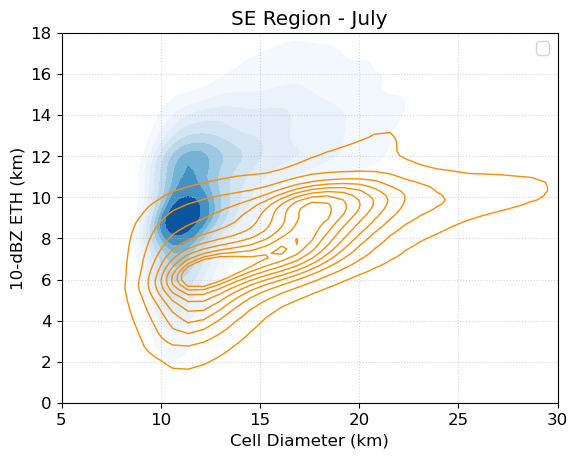

In [60]:
# Example 1: Filter SE region, July data
se_jul_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==7)].dropna(subset=['diameter', 'max_dbz_comp', 'max_echotop10'])
se_jul_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==7)].dropna(subset=['diameter', 'max_dbz_comp', 'max_echotop10'])

print(f"SE July - {name_map['s1']}: {len(se_jul_s1):,} cells")
print(f"SE July - {name_map['s2']}: {len(se_jul_s2):,} cells")

# Quick KDE plot with downsampling
fig, ax = plt.subplots(dpi=100)
levels = np.arange(0.1, 1.01, 0.1)

# Downsample for speed
x_s1, y_s1 = downsample_for_kde(se_jul_s1['diameter'].values, se_jul_s1['max_echotop10'].values)
x_s2, y_s2 = downsample_for_kde(se_jul_s2['diameter'].values, se_jul_s2['max_echotop10'].values)

sns.kdeplot(x=x_s1, y=y_s1, levels=levels, gridsize=100,
            color='darkorange', linewidths=1, fill=False, label=f'{name_map["s2"]}', ax=ax)
sns.kdeplot(x=x_s2, y=y_s2, levels=levels, gridsize=100,
            cmap='Blues', fill=True, label=f'{name_map["s1"]}', ax=ax)
            
ax.set_xlim(5,30)
ax.set_ylim(0,18)
ax.set_xlabel('Cell Diameter (km)')
ax.set_ylabel('10-dBZ ETH (km)')
ax.set_title('SE Region - July')
ax.grid(ls=':', alpha=0.5)
ax.legend()
print(f"Plotted {len(x_s1)} s1 points, {len(x_s2)} s2 points")

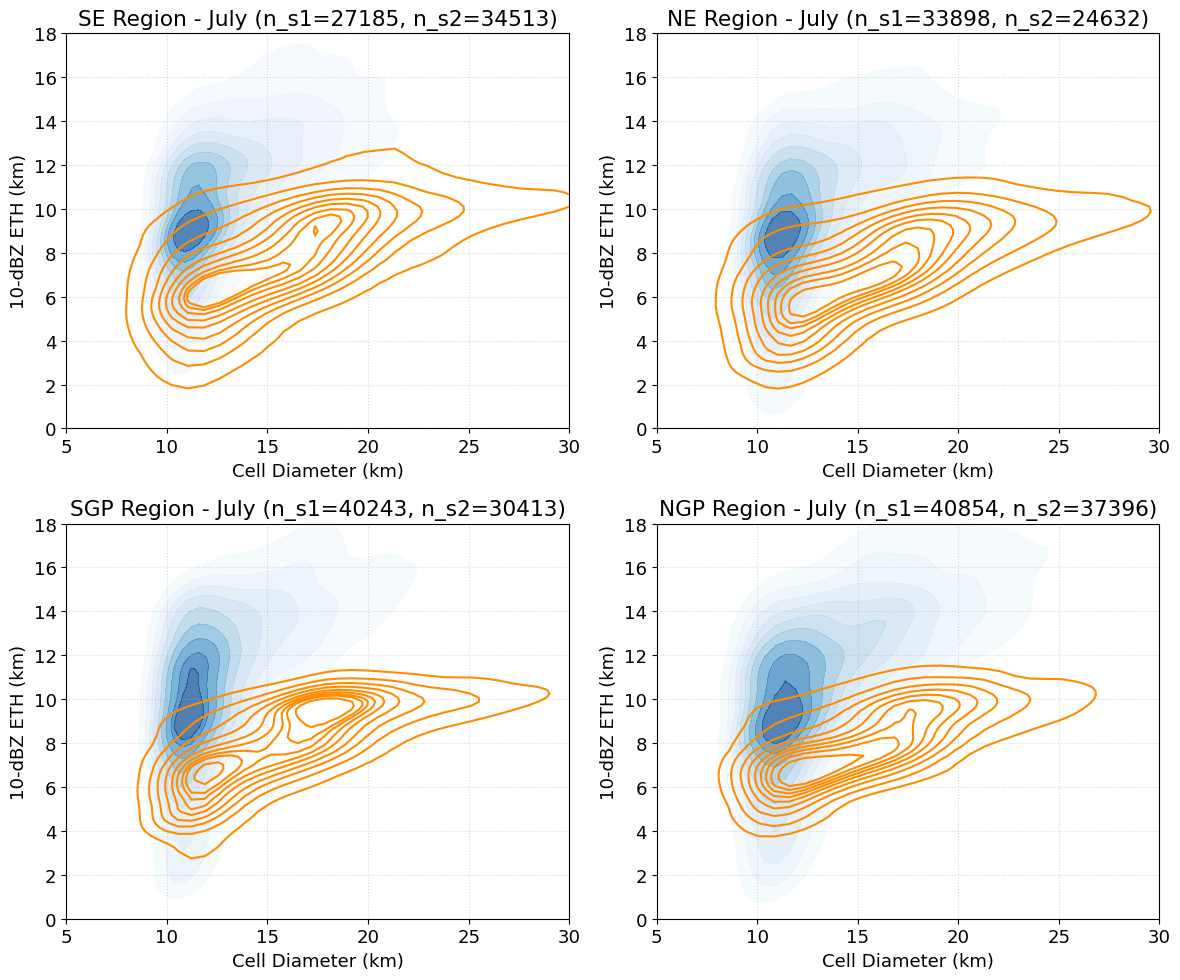

In [ ]:
# Example 2: Compare multiple regions for a single month
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
axes = axes.flatten()

for i, region in enumerate(['SE', 'NE', 'SGP', 'NGP']):
    # Filter data
    region_s1 = df_s1[(df_s1['region']==region) & (df_s1['month']==7)].dropna(subset=['diameter', 'max_echotop10'])
    region_s2 = df_s2[(df_s2['region']==region) & (df_s2['month']==7)].dropna(subset=['diameter', 'max_echotop10'])
    
    if len(region_s1) > 0 and len(region_s2) > 0:
        ax = axes[i]
        levels = np.arange(0.1, 1.01, 0.1)
        
        # Downsample
        x_s1, y_s1 = downsample_for_kde(region_s1['diameter'].values, region_s1['max_echotop10'].values, max_points=5000)
        x_s2, y_s2 = downsample_for_kde(region_s2['diameter'].values, region_s2['max_echotop10'].values, max_points=5000)
        
        sns.kdeplot(x=x_s1, y=y_s1, levels=levels, gridsize=100, 
                    color='darkorange', linewidths=1.5, fill=False, ax=ax)
        sns.kdeplot(x=x_s2, y=y_s2, levels=levels, gridsize=100,
                    cmap='Blues', fill=True, alpha=0.7, ax=ax)
        
        ax.set_xlim(5, 30)
        ax.set_ylim(0, 18)
        ax.set_xlabel('Cell Diameter (km)')
        ax.set_ylabel('10-dBZ ETH (km)')
        ax.set_title(f'{region} Region - July (n_s1={len(region_s1)}, n_s2={len(region_s2)})')
        ax.grid(ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

=== Monthly Mean Cell Diameter by Region ===

SCREAM (SCREAM):
                   mean     median  count
region month                             
NE     4      15.424926  14.361922  24388
       5      15.960677  14.755472  28731
       6      16.262559  15.512649  28991
       7      16.278110  15.512649  33898
       8      16.650120  15.877702  36661
NGP    4      16.052653  14.361922  37152
       5      16.616919  15.138795  39681
       6      16.562211  15.512649  46701
       7      16.047432  15.138795  40854
       8      16.422140  15.877702  57643
SE     4      16.752404  15.138795  16324
       5      16.468708  15.877702  31068
       6      16.490187  15.877702  29046
       7      16.396212  15.877702  27185
       8      16.186157  15.512649  33642
SGP    4      16.938630  15.138795  16792
       5      16.385116  15.138795  27194
       6      15.896993  15.138795  32497
       7      16.089772  15.512649  40243
       8      16.143499  15.512649  48451

GridRad (Gri

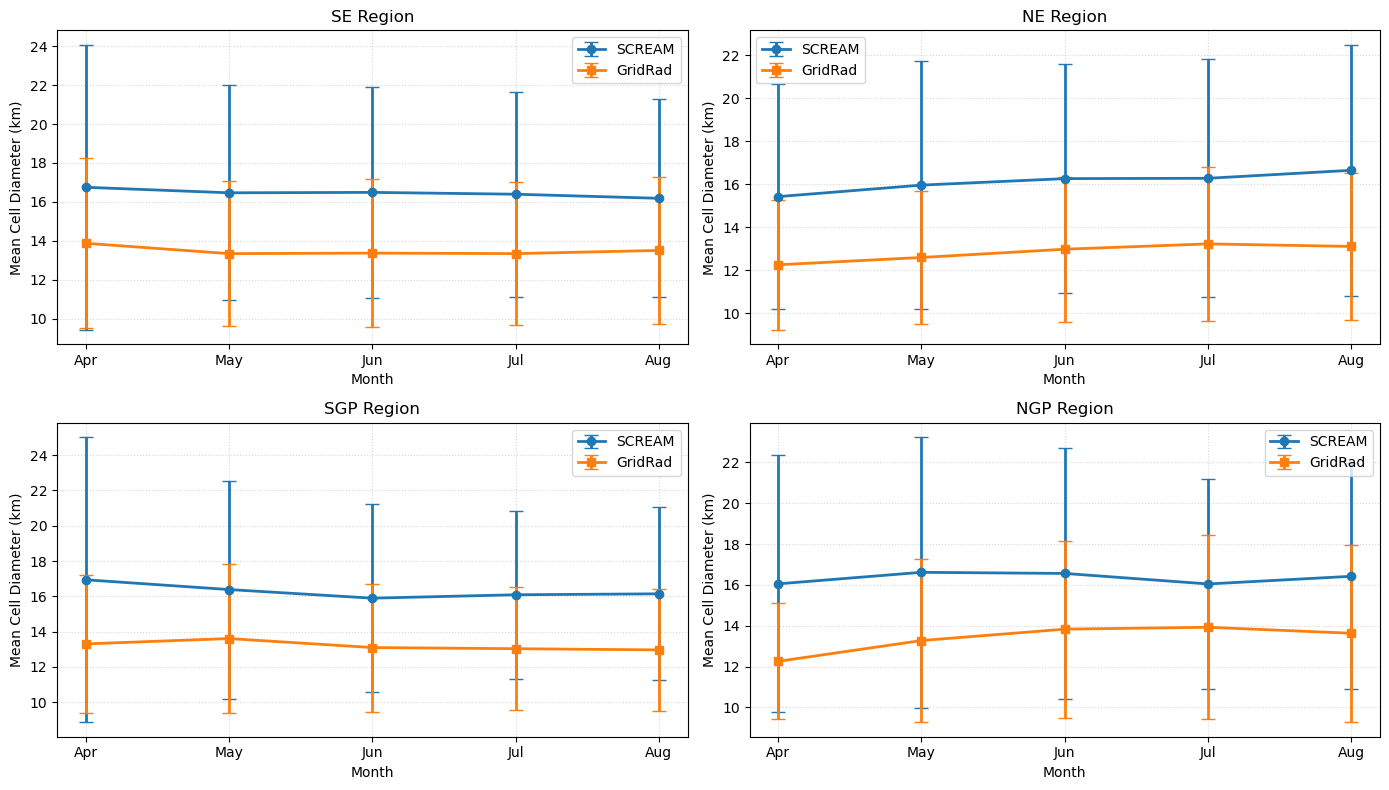

In [49]:
# Example 3: Compute monthly statistics by region using groupby
print("=== Monthly Mean Cell Diameter by Region ===\n")

# SCREAM
print(f"{name_map['s1']} (SCREAM):")
stats_s1 = df_s1.groupby(['region', 'month'])['diameter'].agg(['mean', 'median', 'count'])
print(stats_s1)

print(f"\n{name_map['s2']} (GridRad):")
stats_s2 = df_s2.groupby(['region', 'month'])['diameter'].agg(['mean', 'median', 'count'])
print(stats_s2)

# Visualize monthly evolution for each region
fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=100)
axes = axes.flatten()

for i, region in enumerate(['SE', 'NE', 'SGP', 'NGP']):
    ax = axes[i]
    
    # Get data for this region
    region_s1 = df_s1[df_s1['region']==region].groupby('month')['diameter'].agg(['mean', 'std', 'count'])
    region_s2 = df_s2[df_s2['region']==region].groupby('month')['diameter'].agg(['mean', 'std', 'count'])
    
    # Plot
    if len(region_s1) > 0:
        ax.errorbar(region_s1.index, region_s1['mean'], yerr=region_s1['std'], 
                    marker='o', label=name_map['s1'], capsize=5, linewidth=2)
    if len(region_s2) > 0:
        ax.errorbar(region_s2.index, region_s2['mean'], yerr=region_s2['std'], 
                    marker='s', label=name_map['s2'], capsize=5, linewidth=2)
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Cell Diameter (km)')
    ax.set_title(f'{region} Region')
    ax.legend()
    ax.grid(ls=':', alpha=0.5)
    ax.set_xticks([4, 5, 6, 7, 8])
    ax.set_xticklabels(['Apr', 'May', 'Jun', 'Jul', 'Aug'])

plt.tight_layout()
plt.show()

In [50]:
# Example 4: Advanced filtering combinations
print("=== Advanced Filtering Examples ===\n")

# Example: Large cells (diameter > 20 km) in SE region during summer
large_se_summer_s1 = df_s1[
    (df_s1['region'] == 'SE') & 
    (df_s1['month'].isin([6, 7, 8])) & 
    (df_s1['diameter'] > 20)
]
print(f"Large cells (>20km) in SE region (summer): {len(large_se_summer_s1):,}")

# Example: All regions except NGP, July only
not_ngp_jul_s1 = df_s1[
    (df_s1['region'].isin(['SE', 'NE', 'SGP'])) & 
    (df_s1['month'] == 7)
]
print(f"All regions except NGP (July): {len(not_ngp_jul_s1):,}")

# Example: Intense cells with high echo top
intense_cells_s1 = df_s1[
    (df_s1['max_dbz_comp'] > 55) & 
    (df_s1['max_echotop10'] > 12) &
    (df_s1['region'].notna())  # Only cells with assigned region
]
print(f"Intense cells (DBZ>55, ETH10>12km) all regions: {len(intense_cells_s1):,}")
print(f"  By region: {intense_cells_s1['region'].value_counts().to_dict()}")

# Example: Cross-tabulation
print("\n=== Cell counts by region and month (SCREAM) ===")
crosstab = pd.crosstab(df_s1['region'], df_s1['month'], margins=True)
print(crosstab)

=== Advanced Filtering Examples ===

Large cells (>20km) in SE region (summer): 16,159
All regions except NGP (July): 101,326
Intense cells (DBZ>55, ETH10>12km) all regions: 12,600
  By region: {'SE': 4551, 'NE': 3042, 'NGP': 2776, 'SGP': 2231}

=== Cell counts by region and month (SCREAM) ===
month       4       5       6       7       8     All
region                                               
NE      24388   28731   28991   33898   36661  152669
NGP     37152   39681   46701   40854   57643  222031
SE      16324   31068   29046   27185   33642  137265
SGP     16792   27194   32497   40243   48451  165177
All     94656  126674  137235  142180  176397  677142


## Function to plot MxN panel JointKDE

In [54]:
mpl.rcParams['font.family'] = 'sans-serif'

In [86]:
def jointKDE_MxN(nrow, ncol, data, margin_space=0.01, levels=None, gridsize=None, bw_adjust=None,
                 cmap=None, lcolors=None, suptitle=None, fontsize=None,
                 titles=None, xlims=None, ylims=None, xlabels=None, ylabels=None, legend_loc='best', legend_labels=None, 
                 wspace=0.5, hspace=0.5,
                 dpi=300, figsize=None, figname=None):
    
    # mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize

    if figsize is None: figsize=(6 * ncol, 6 * nrow)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = gridspec.GridSpec(nrow, ncol, wspace=wspace, hspace=hspace)
    
    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    lw_joint = 2
    lw_fit = 5

    # Create a KDE plot with marginals for each cell in the grid
    for row in range(nrow):
        for col in range(ncol):
            # idx = i * ncol + j
            # x, y = data[idx]
            if (data[row][col] is not None):
                x_o, y_o = data[row][col]['o']
                x_m, y_m = data[row][col]['m']
                if (col==0): lc_m = lcolors['m1']
                if (col==1): lc_m = lcolors['m2']
                if (col==2): lc_m = lcolors['m3']
                # legend_lab = legend_labels[row][col]
                # legend_m = legend_labels[row][col]

                # Set up main axes for joint KDE plot in the GridSpec layout
                ax_joint = fig.add_subplot(gs[row, col])

                # Plot joint KDE
                sns.kdeplot(x=x_o, y=y_o, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=ax_joint, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(x=x_m, y=y_m, color=lc_m, levels=levels, linewidths=lw_joint, fill=False, ax=ax_joint, gridsize=gridsize, bw_adjust=bw_adjust)
                ax_joint.set_xlabel(xlabels[row][col])
                ax_joint.set_ylabel(ylabels[row][col])
                ax_joint.grid(ls=':')
                
                # Linear regression (OBS)
                mask = ~np.isnan(x_o) & ~np.isnan(y_o)
                linfit = linregress(x=x_o[mask], y=y_o[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_o), np.nanmax(x_o), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                yfit_label_o = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lcolors['o'], lw=lw_fit, label=yfit_label_o, zorder=5)

                # Linear regression (MODEL)
                mask = ~np.isnan(x_m) & ~np.isnan(y_m)
                linfit = linregress(x=x_m[mask], y=y_m[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_m), np.nanmax(x_m), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                yfit_label_m = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lc_m, lw=lw_fit, label=yfit_label_m, zorder=5)
                
                # Create marginal axes with a small space between them and ax_joint
                pos = ax_joint.get_position()
                ax_marg_x = fig.add_axes([pos.x0, pos.y1 + margin_space, pos.width, 0.2 * pos.height])
                ax_marg_y = fig.add_axes([pos.x1 + margin_space, pos.y0, 0.2 * pos.width, pos.height])
                ax_marg_x.grid(axis='x', ls=':')
                ax_marg_y.grid(axis='y', ls=':')
                
                # Set x and y limits for ax_joint and apply to the marginal plots
                if xlims:
                    ax_joint.set_xlim(xlims[row][col])
                    ax_marg_x.set_xlim(xlims[row][col])
                if ylims:
                    ax_joint.set_ylim(ylims[row][col])
                    ax_marg_y.set_ylim(ylims[row][col])

                # Plot marginal KDEs on the marginal axes
                sns.kdeplot(x=x_o, ax=ax_marg_x, color=lcolors['o'], lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(y=y_o, ax=ax_marg_y, color=lcolors['o'], lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(x=x_m, ax=ax_marg_x, color=lc_m, lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(y=y_m, ax=ax_marg_y, color=lc_m, lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                
                # # Adjust ylim of marginal plots to avoid cutting off the KDE line
                # y_lim_x = ax_marg_x.get_ylim()
                # ax_marg_x.set_ylim(y_lim_x[0] * 1.1, y_lim_x[1] * 1.1)  # Increase upper limit by 10%
                # y_lim_y = ax_marg_y.get_xlim()
                # ax_marg_y.set_xlim(y_lim_y[0] * 1.1, y_lim_y[1] * 1.1)  # Increase upper limit by 10%
                
                # Add title within the ax_joint at the upper left corner
                ax_joint.text(
                    0.02, 0.98,  # Position in axis coordinates
                    titles[row][col],
                    ha='left', va='top',
                    transform=ax_joint.transAxes,
                    # fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                )
                
                # Legends
                # ax_joint.legend(loc=legend_loc)
                legend_elements = [mpl.patches.Patch(facecolor=cmap(0.2), edgecolor='gray'),
                                   mpl.lines.Line2D([0], [0], color=lc_m, lw=lw_joint)]
                _legend_labels = [f"{legend_labels[row][col][0]} ({yfit_label_o})",
                                  f"{legend_labels[row][col][1]} ({yfit_label_m})"]
                ax_joint.legend(handles=legend_elements, labels=_legend_labels, 
                                loc=legend_loc, facecolor='w', 
                                prop={'size': fontsize*0.8},
                                # prop={'family':'Helvetica', 'size':18},
                               )

                # Remove tick labels and borders on the marginal plots
                ax_marg_x.set(yticks=[], ylabel=None)
                ax_marg_x.set_xticklabels([])  # Remove x-axis tick labels
                ax_marg_y.set(xticks=[], xlabel=None)
                ax_marg_y.set_yticklabels([])  # Remove y-axis tick labels
                ax_marg_x.tick_params(left=False, bottom=False)
                ax_marg_y.tick_params(left=False, bottom=False)
                # Show only the bottom spine (x-axis) for ax_marg_x and left spine (y-axis) for ax_marg_y
                ax_marg_x.spines['top'].set_visible(False)
                ax_marg_x.spines['right'].set_visible(False)
                ax_marg_x.spines['left'].set_visible(False)
                ax_marg_y.spines['top'].set_visible(False)
                ax_marg_y.spines['right'].set_visible(False)
                ax_marg_y.spines['bottom'].set_visible(False)
                # # Hide all spines
                # for spine in ax_marg_x.spines.values():
                #     spine.set_visible(False)
                # for spine in ax_marg_y.spines.values():
                #     spine.set_visible(False)

    if (suptitle): fig.suptitle(suptitle, weight='bold')
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

In [87]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

Preparing data for SE region by month...
  Apr: SCREAM=16324, GridRad=10150 cells
  May: SCREAM=31068, GridRad=18586 cells
  Jun: SCREAM=29046, GridRad=23633 cells
  Jul: SCREAM=27185, GridRad=34513 cells
  Aug: SCREAM=33642, GridRad=33643 cells

Creating joint KDE plot...
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/JointKDE_CellDiameter_vs_ETH10_byMonth_SCREAM_vs_GridRad_SE.png


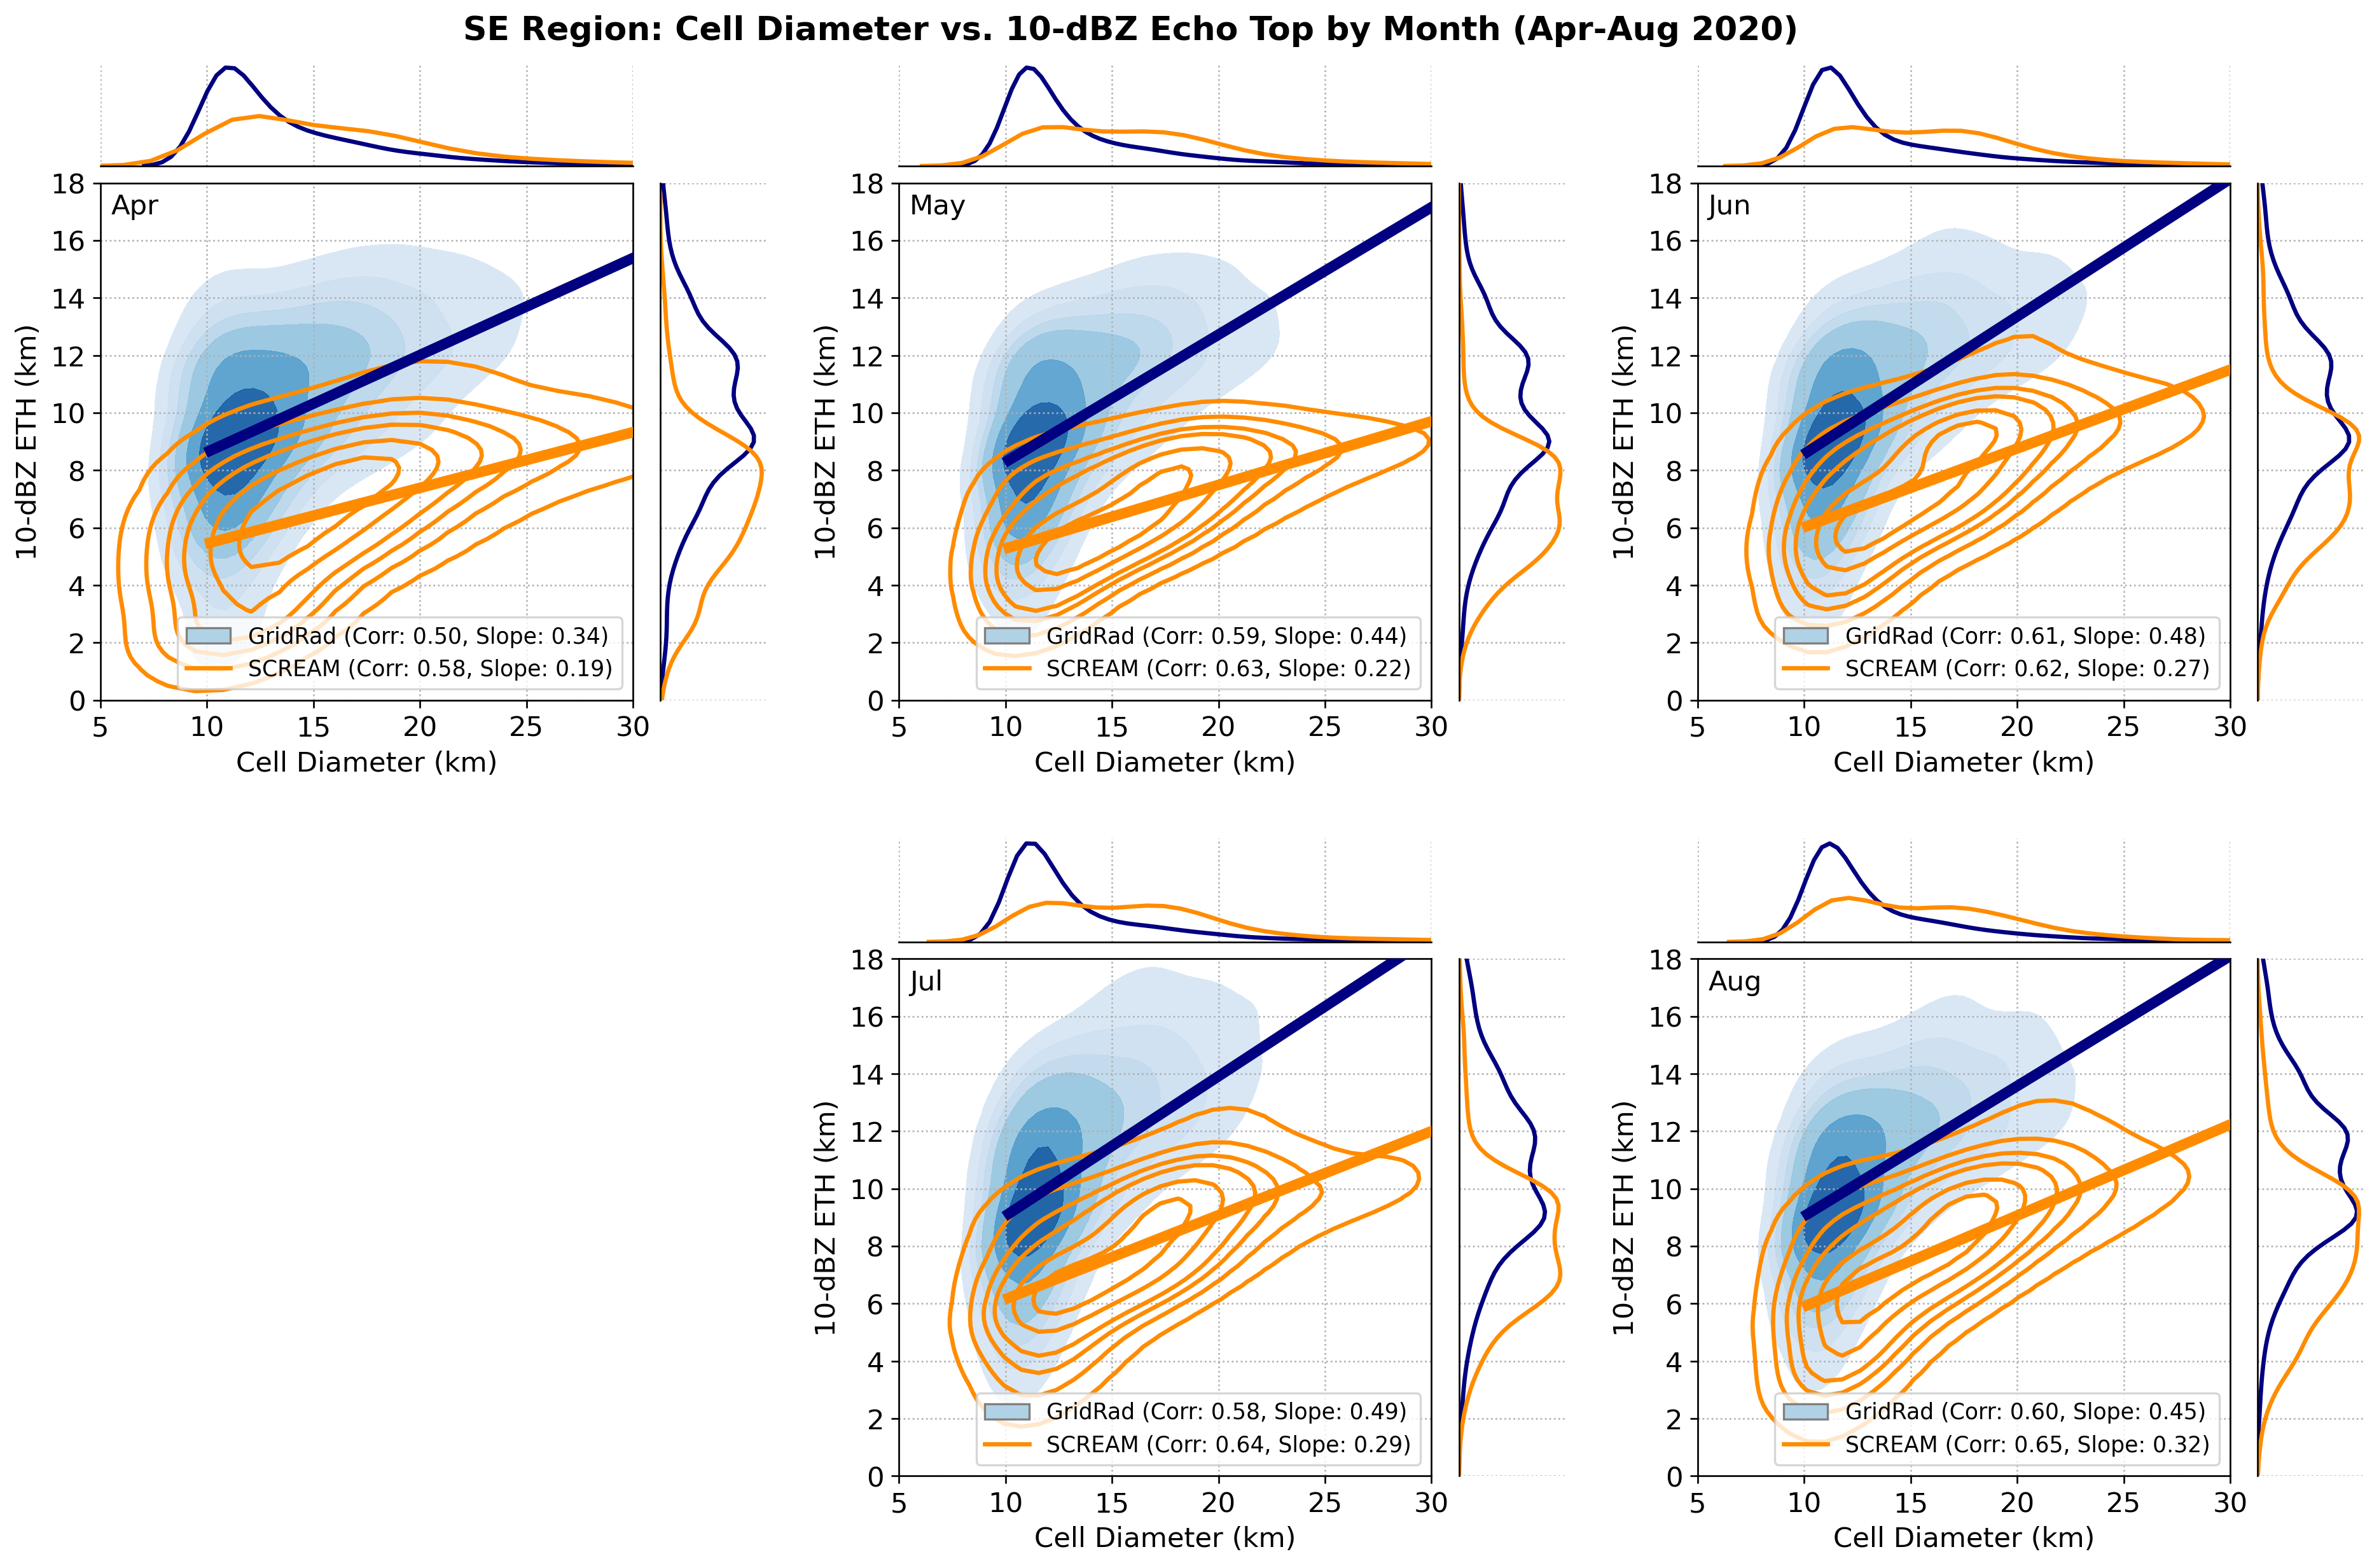

In [88]:
# Plot SE region: Cell Diameter vs. Max Echo Top 10-dBZ by Month
# Layout: 2x3 panels (Row1: Apr, May, Jun; Row2: empty, Jul, Aug)

nrow = 2
ncol = 3

# Max number of randomly sample points
max_points = 10000

# Month names
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

# Prepare data structure
data = [[None for _ in range(ncol)] for _ in range(nrow)]
titles = [[None for _ in range(ncol)] for _ in range(nrow)]
xlims = [[None for _ in range(ncol)] for _ in range(nrow)]
ylims = [[None for _ in range(ncol)] for _ in range(nrow)]
xlabels = [[None for _ in range(ncol)] for _ in range(nrow)]
ylabels = [[None for _ in range(ncol)] for _ in range(nrow)]
legend_labels = [[None for _ in range(ncol)] for _ in range(nrow)]

print("Preparing data for SE region by month...")

# Row 1: Apr, May, Jun (columns 0, 1, 2)
for col, month in enumerate([4, 5, 6]):
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_echotop10'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_echotop10'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_echotop10'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_echotop10'].values, max_points=max_points)
    
    data[0][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[0][col] = month_names[month]
    xlims[0][col] = (5, 30)
    ylims[0][col] = (0, 18)
    xlabels[0][col] = 'Cell Diameter (km)'
    ylabels[0][col] = '10-dBZ ETH (km)'
    legend_labels[0][col] = [name_map['s2'], name_map['s1']]

# Row 2: empty, Jul, Aug (column 0 is None, columns 1-2 have data)
data[1][0] = None  # Empty panel
titles[1][0] = None
xlims[1][0] = None
ylims[1][0] = None
xlabels[1][0] = None
ylabels[1][0] = None
legend_labels[1][0] = None

for i, month in enumerate([7, 8]):
    col = i + 1  # Start from column 1 (skip column 0)
    
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_echotop10'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_echotop10'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_echotop10'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_echotop10'].values, max_points=max_points)
    
    data[1][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[1][col] = month_names[month]
    xlims[1][col] = (5, 30)
    ylims[1][col] = (0, 18)
    xlabels[1][col] = 'Cell Diameter (km)'
    ylabels[1][col] = '10-dBZ ETH (km)'
    legend_labels[1][col] = [name_map['s2'], name_map['s1']]

# Set up plot parameters
# levels = np.arange(0.1, 1.01, 0.1)
levels = [0.1,0.2,0.3,0.4,0.6,0.8,1]
cmap = plt.get_cmap('Blues')  # For GridRad shaded contours
cmap = truncate_colormap(cmap, 0.15, 1)
lcolors = {
    'o': 'navy',         # GridRad marginal and fit line
    'm1': 'darkorange',  # SCREAM contours (all same color)
    'm2': 'darkorange',
    'm3': 'darkorange'
}

figname = f'{figdir}JointKDE_CellDiameter_vs_ETH10_byMonth_{name_map["s1"]}_vs_{name_map["s2"]}_SE.png'

print("\nCreating joint KDE plot...")
fig = jointKDE_MxN(
    nrow=nrow, 
    ncol=ncol, 
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'SE Region: Cell Diameter vs. 10-dBZ Echo Top by Month (Apr-Aug 2020)',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='lower right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=240,
    figsize=(18, 11),
    figname=figname
)

print(f"Saved: {figname}")


Preparing data for SE region by month...
  Apr: SCREAM=15076, GridRad=9326 cells


  May: SCREAM=29286, GridRad=16347 cells
  Jun: SCREAM=27504, GridRad=20612 cells
  Jul: SCREAM=25709, GridRad=30187 cells
  Aug: SCREAM=31468, GridRad=30276 cells

Creating joint KDE plot...
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/JointKDE_CellDiameter_vs_ETH30_byMonth_SCREAM_vs_GridRad_SE.png


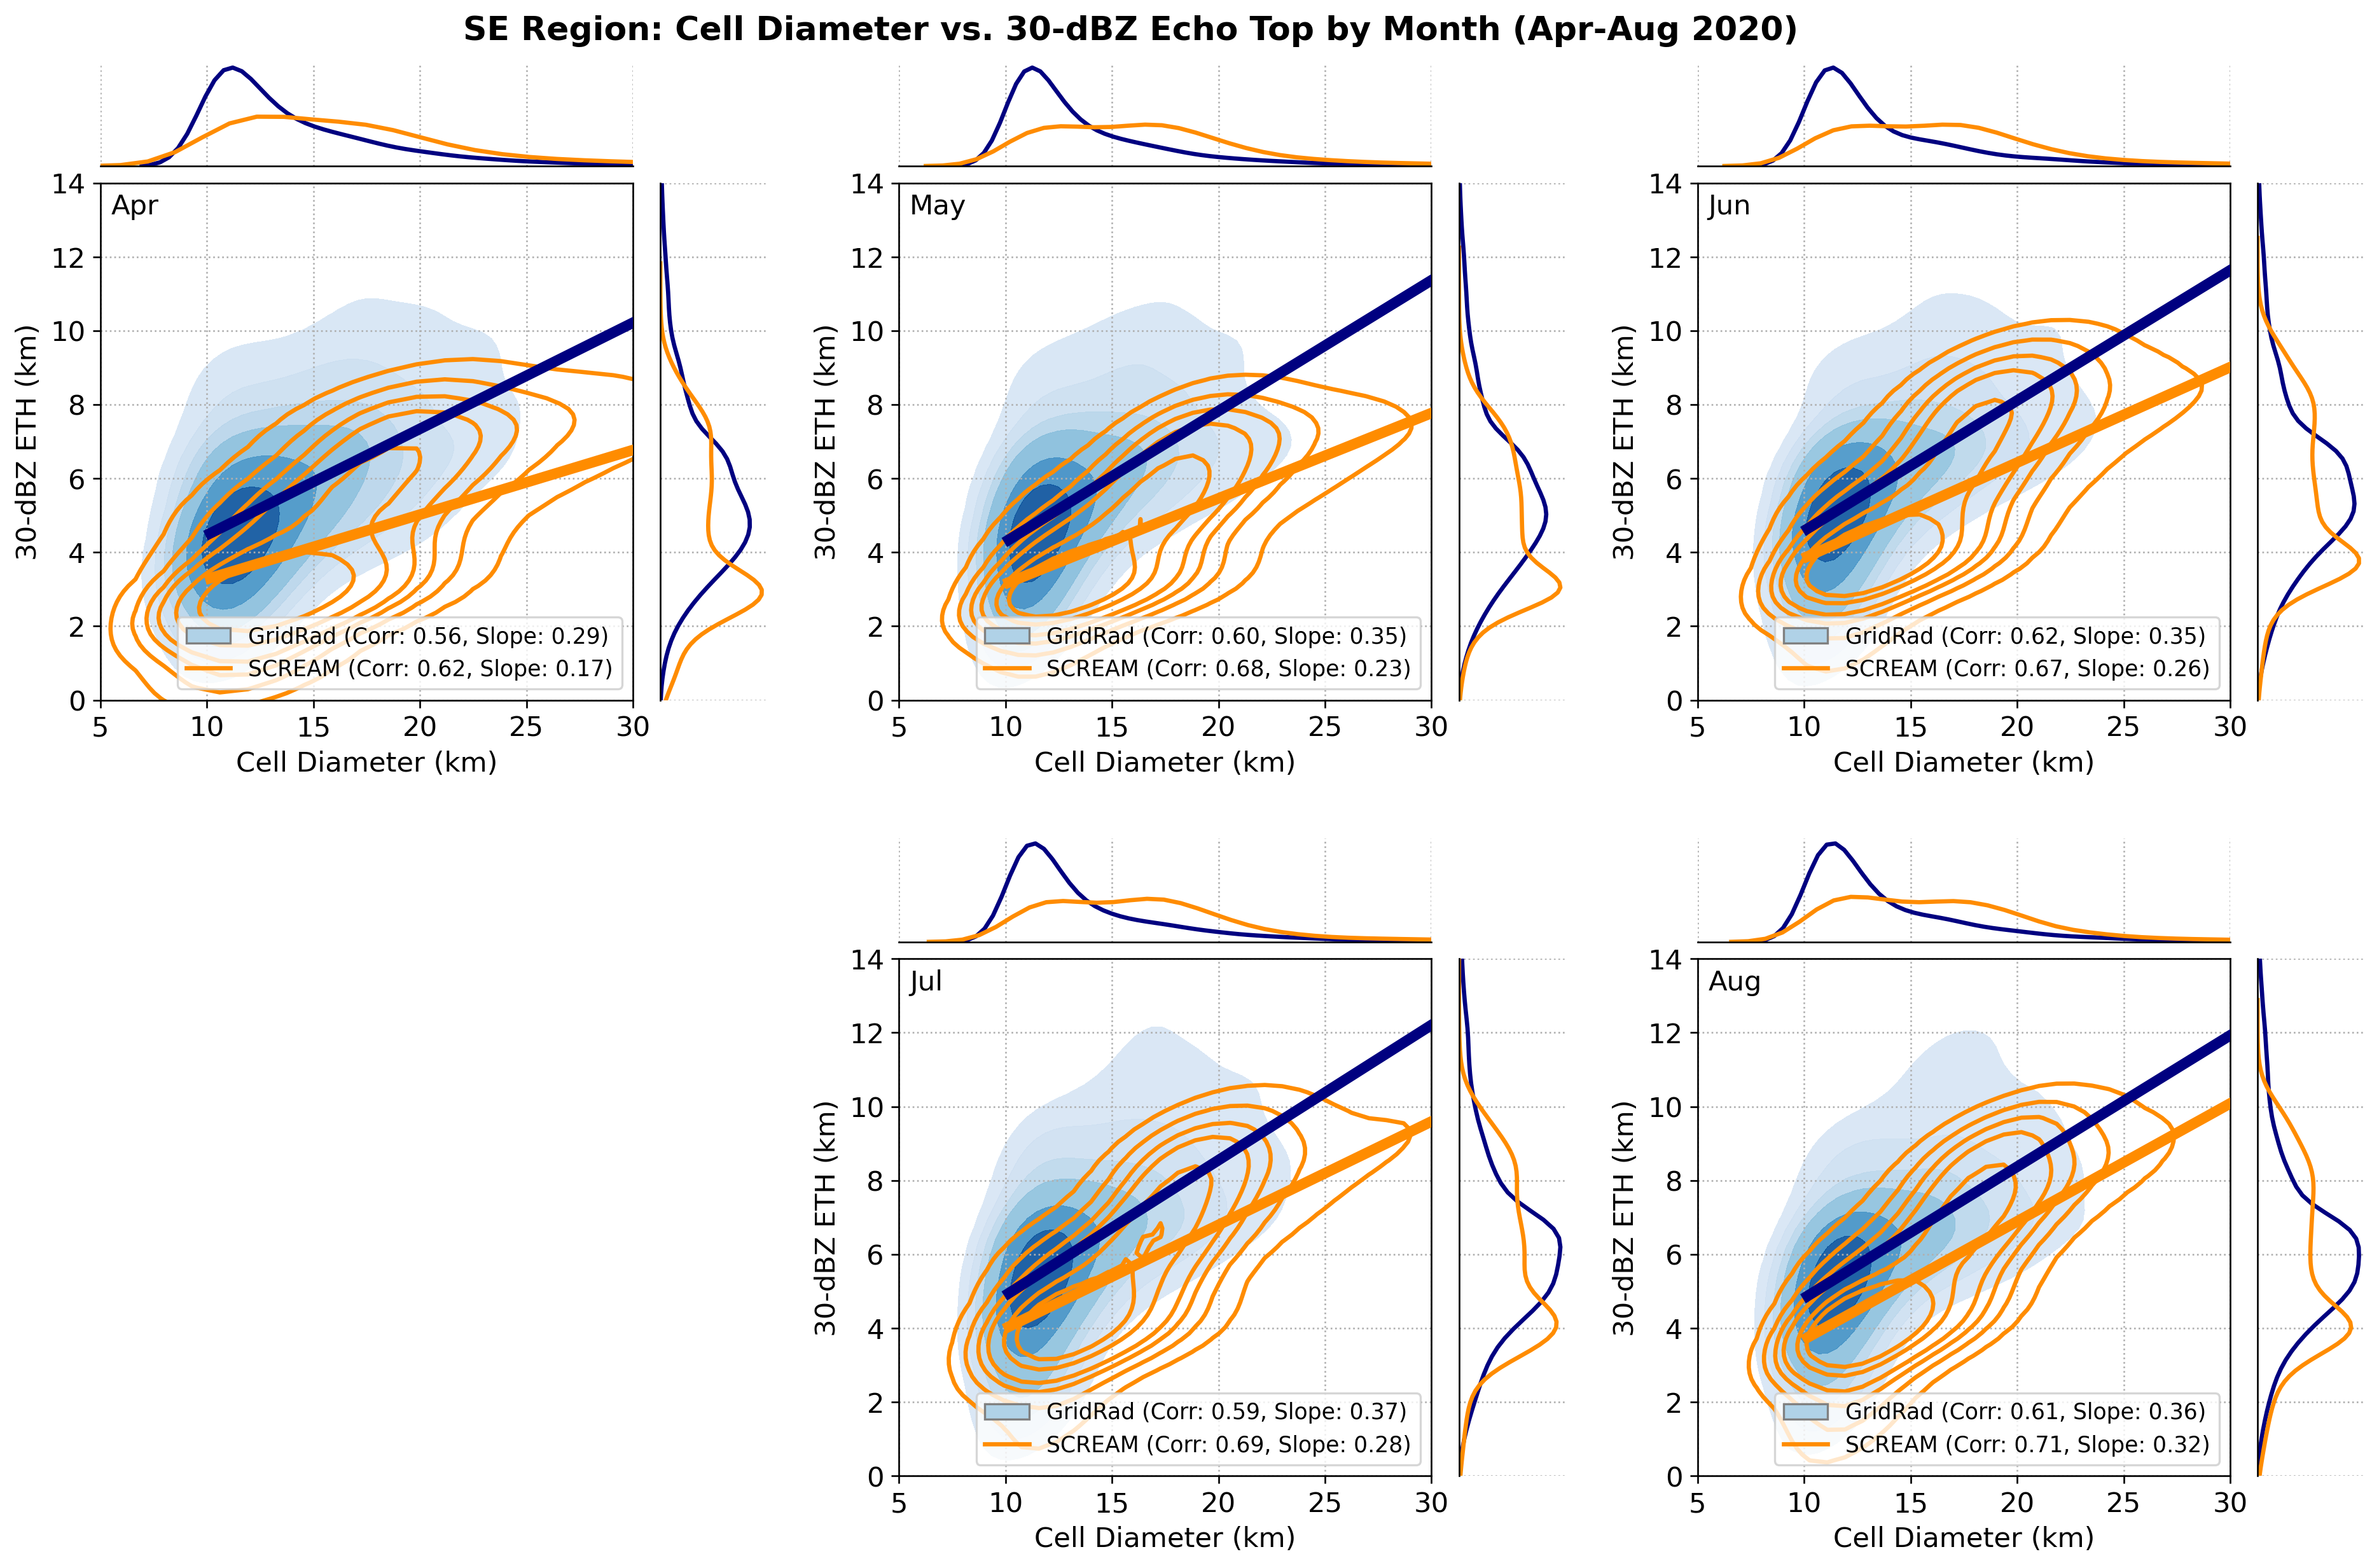

In [89]:
# Plot SE region: Cell Diameter vs. Max Echo Top 30-dBZ by Month
# Layout: 2x3 panels (Row1: Apr, May, Jun; Row2: empty, Jul, Aug)

nrow = 2
ncol = 3

# Max number of randomly sample points
max_points = 10000

# Month names
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

x_lim = (5, 30)
y_lim = (0, 14)

# Prepare data structure
data = [[None for _ in range(ncol)] for _ in range(nrow)]
titles = [[None for _ in range(ncol)] for _ in range(nrow)]
xlims = [[None for _ in range(ncol)] for _ in range(nrow)]
ylims = [[None for _ in range(ncol)] for _ in range(nrow)]
xlabels = [[None for _ in range(ncol)] for _ in range(nrow)]
ylabels = [[None for _ in range(ncol)] for _ in range(nrow)]
legend_labels = [[None for _ in range(ncol)] for _ in range(nrow)]

print("Preparing data for SE region by month...")

# Row 1: Apr, May, Jun (columns 0, 1, 2)
for col, month in enumerate([4, 5, 6]):
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_echotop30'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_echotop30'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_echotop30'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_echotop30'].values, max_points=max_points)
    
    data[0][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[0][col] = month_names[month]
    xlims[0][col] = x_lim
    ylims[0][col] = y_lim
    xlabels[0][col] = 'Cell Diameter (km)'
    ylabels[0][col] = '30-dBZ ETH (km)'
    legend_labels[0][col] = [name_map['s2'], name_map['s1']]

# Row 2: empty, Jul, Aug (column 0 is None, columns 1-2 have data)
data[1][0] = None  # Empty panel
titles[1][0] = None
xlims[1][0] = None
ylims[1][0] = None
xlabels[1][0] = None
ylabels[1][0] = None
legend_labels[1][0] = None

for i, month in enumerate([7, 8]):
    col = i + 1  # Start from column 1 (skip column 0)
    
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_echotop30'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_echotop30'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_echotop30'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_echotop30'].values, max_points=max_points)
    
    data[1][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[1][col] = month_names[month]
    xlims[1][col] = x_lim
    ylims[1][col] = y_lim
    xlabels[1][col] = 'Cell Diameter (km)'
    ylabels[1][col] = '30-dBZ ETH (km)'
    legend_labels[1][col] = [name_map['s2'], name_map['s1']]

# Set up plot parameters
# levels = np.arange(0.1, 1.01, 0.1)
levels = [0.1,0.2,0.3,0.4,0.6,0.8,1]
cmap = plt.get_cmap('Blues')  # For GridRad shaded contours
cmap = truncate_colormap(cmap, 0.15, 1)
lcolors = {
    'o': 'navy',         # GridRad marginal and fit line
    'm1': 'darkorange',  # SCREAM contours (all same color)
    'm2': 'darkorange',
    'm3': 'darkorange'
}

figname = f'{figdir}JointKDE_CellDiameter_vs_ETH30_byMonth_{name_map["s1"]}_vs_{name_map["s2"]}_SE.png'

print("\nCreating joint KDE plot...")
fig = jointKDE_MxN(
    nrow=nrow, 
    ncol=ncol, 
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'SE Region: Cell Diameter vs. 30-dBZ Echo Top by Month (Apr-Aug 2020)',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='lower right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=240,
    figsize=(18, 11),
    figname=figname
)

print(f"Saved: {figname}")


In [90]:
df_s1.keys()

Index(['time', 'cell_id', 'filename', 'npixels', 'area', 'diameter',
       'center_lon', 'center_lat', 'max_dbz_comp', 'max_dbz_lowlevel',
       'max_echotop10', 'max_echotop20', 'max_echotop30', 'max_echotop40',
       'max_echotop50', 'month', 'region'],
      dtype='str')

Preparing data for SE region by month...
  Apr: SCREAM=16324, GridRad=10150 cells
  May: SCREAM=31068, GridRad=18586 cells
  Jun: SCREAM=29046, GridRad=23633 cells
  Jul: SCREAM=27185, GridRad=34513 cells
  Aug: SCREAM=33642, GridRad=33643 cells

Creating joint KDE plot...
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/JointKDE_CellDiameter_vs_MaxReflectivity_byMonth_SCREAM_vs_GridRad_SE.png


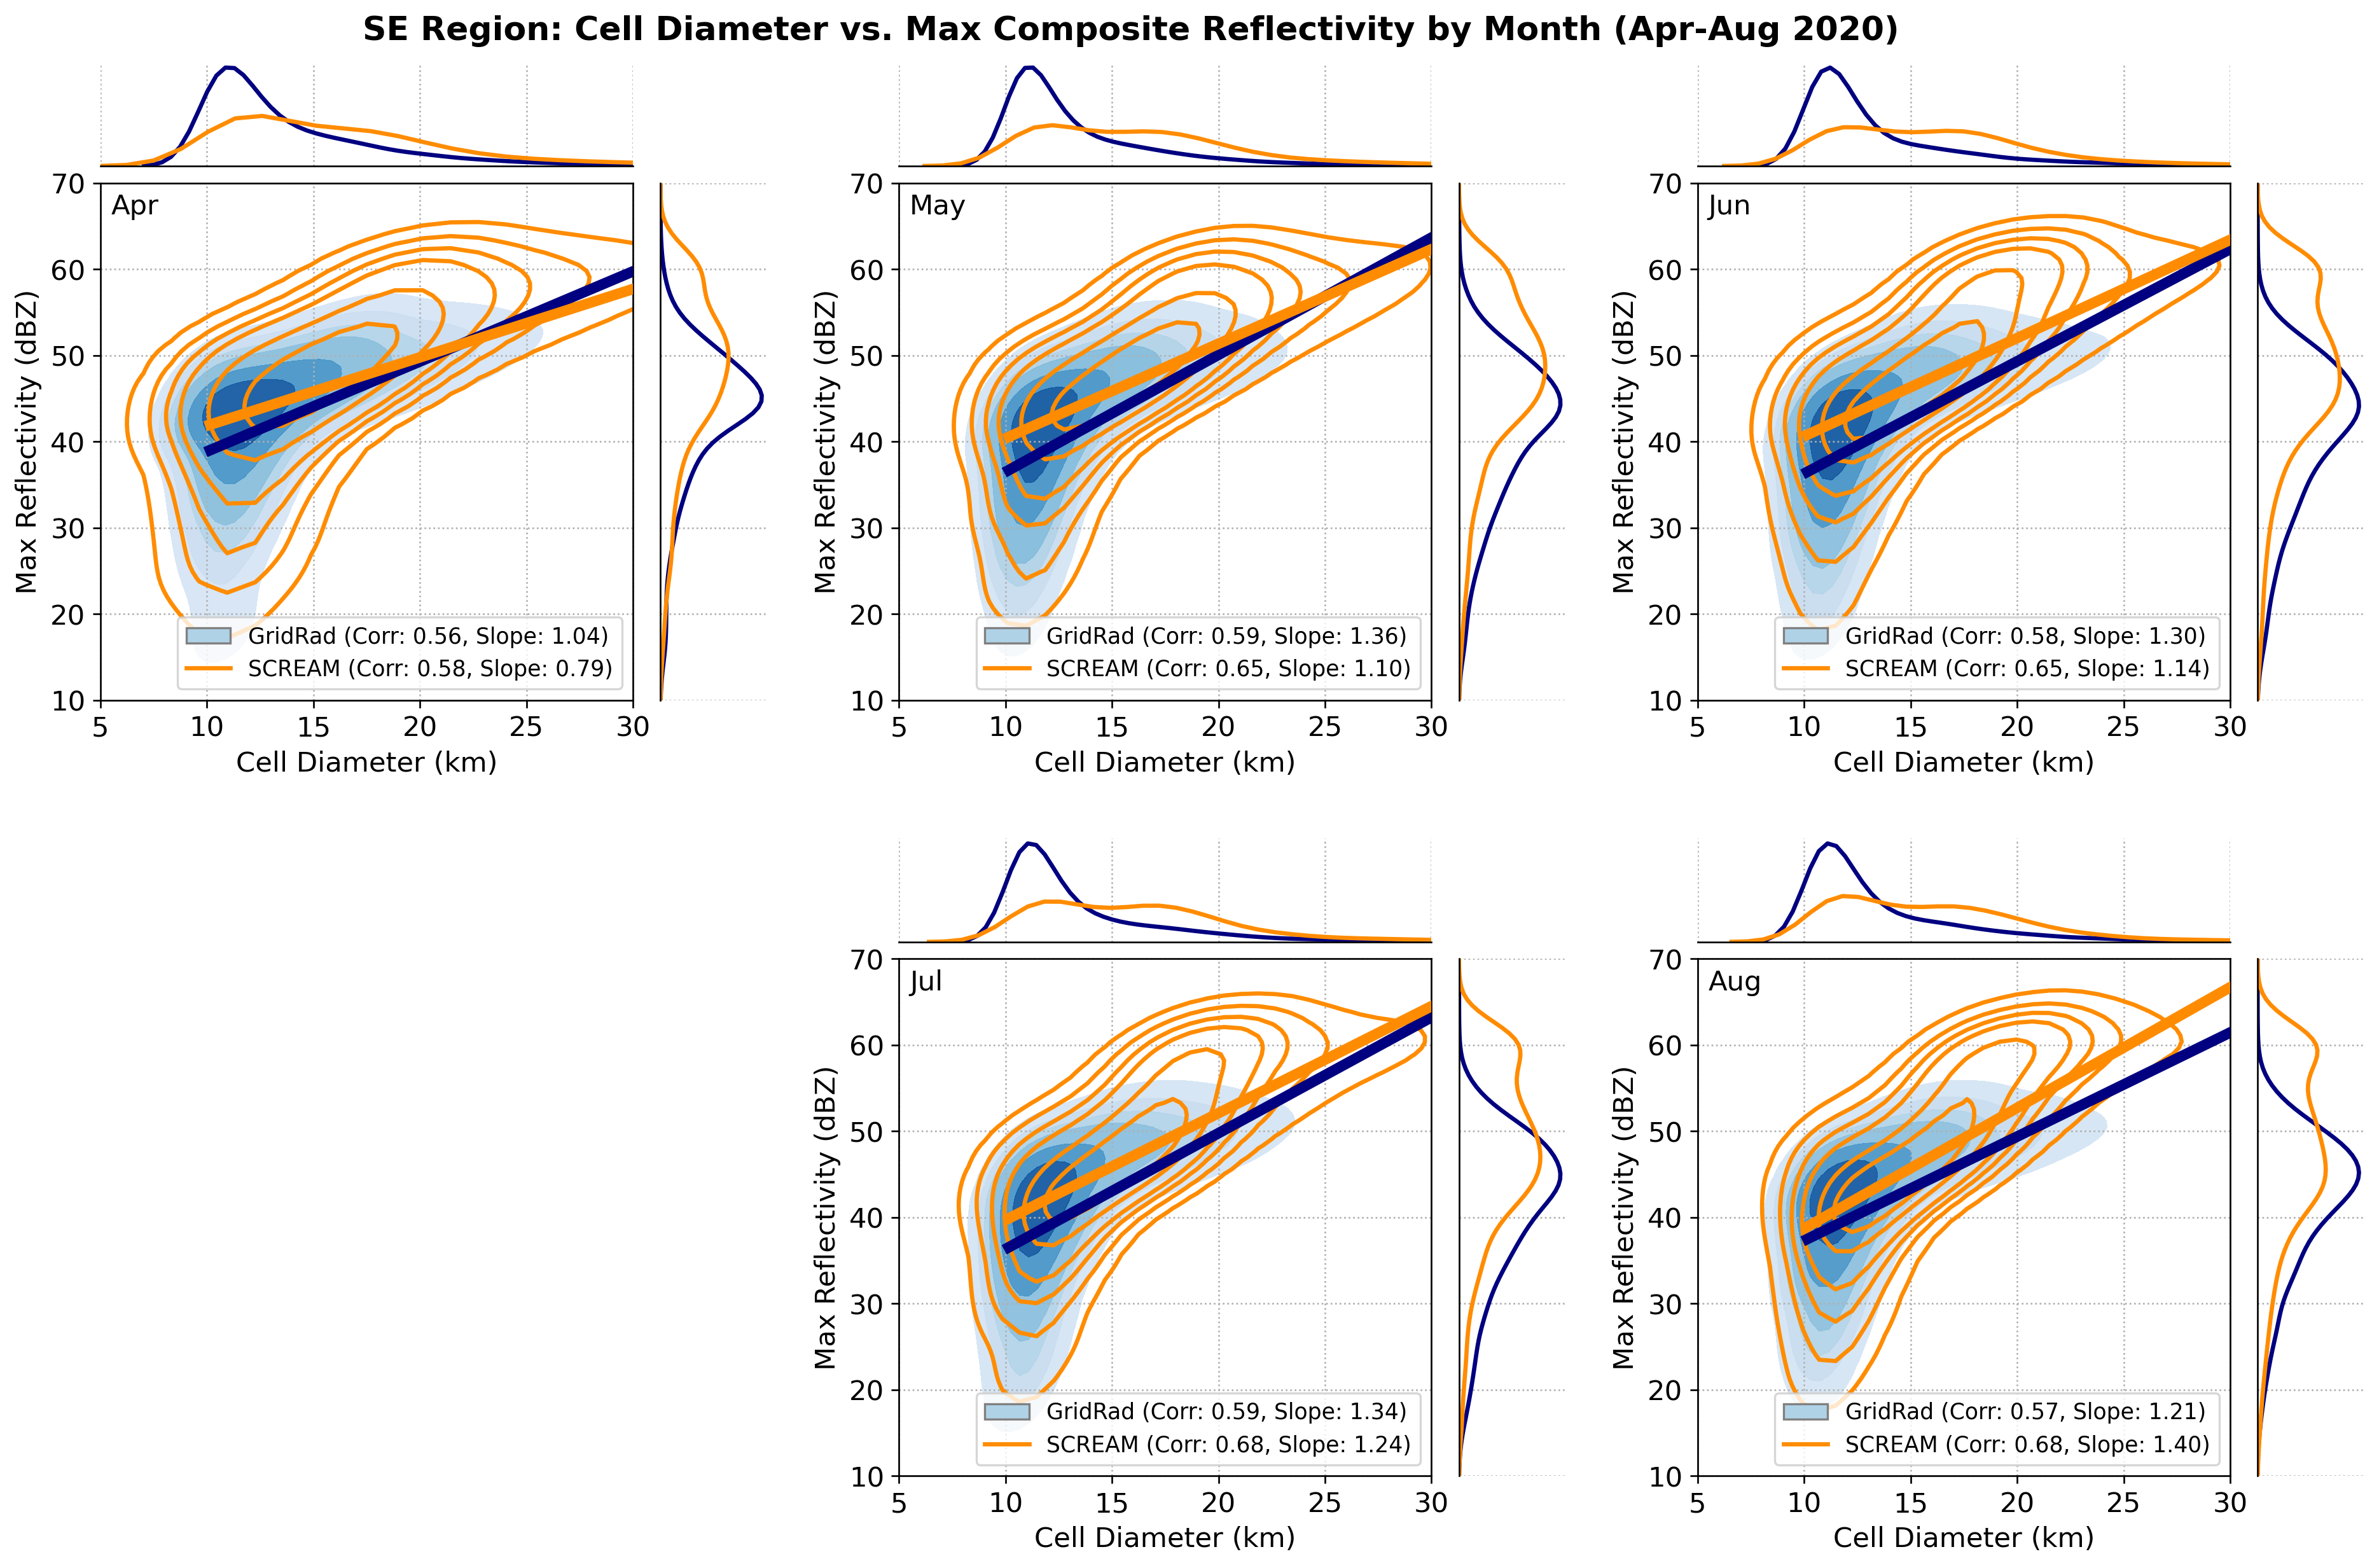

In [93]:
# Plot SE region: Cell Diameter vs. Max Echo Top 30-dBZ by Month
# Layout: 2x3 panels (Row1: Apr, May, Jun; Row2: empty, Jul, Aug)

nrow = 2
ncol = 3

# Max number of randomly sample points
max_points = 10000

# Month names
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

x_lim = (5, 30)
y_lim = (10, 70)

# Prepare data structure
data = [[None for _ in range(ncol)] for _ in range(nrow)]
titles = [[None for _ in range(ncol)] for _ in range(nrow)]
xlims = [[None for _ in range(ncol)] for _ in range(nrow)]
ylims = [[None for _ in range(ncol)] for _ in range(nrow)]
xlabels = [[None for _ in range(ncol)] for _ in range(nrow)]
ylabels = [[None for _ in range(ncol)] for _ in range(nrow)]
legend_labels = [[None for _ in range(ncol)] for _ in range(nrow)]

print("Preparing data for SE region by month...")

# Row 1: Apr, May, Jun (columns 0, 1, 2)
for col, month in enumerate([4, 5, 6]):
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_dbz_comp'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_dbz_comp'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_dbz_comp'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_dbz_comp'].values, max_points=max_points)
    
    data[0][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[0][col] = month_names[month]
    xlims[0][col] = x_lim
    ylims[0][col] = y_lim
    xlabels[0][col] = 'Cell Diameter (km)'
    ylabels[0][col] = 'Max Reflectivity (dBZ)'
    legend_labels[0][col] = [name_map['s2'], name_map['s1']]

# Row 2: empty, Jul, Aug (column 0 is None, columns 1-2 have data)
data[1][0] = None  # Empty panel
titles[1][0] = None
xlims[1][0] = None
ylims[1][0] = None
xlabels[1][0] = None
ylabels[1][0] = None
legend_labels[1][0] = None

for i, month in enumerate([7, 8]):
    col = i + 1  # Start from column 1 (skip column 0)
    
    # Filter SE region for this month
    se_s1 = df_s1[(df_s1['region']=='SE') & (df_s1['month']==month)].dropna(subset=['diameter', 'max_dbz_comp'])
    se_s2 = df_s2[(df_s2['region']=='SE') & (df_s2['month']==month)].dropna(subset=['diameter', 'max_dbz_comp'])
    
    print(f"  {month_names[month]}: SCREAM={len(se_s1)}, GridRad={len(se_s2)} cells")
    
    # Downsample for faster plotting
    x_s1, y_s1 = downsample_for_kde(se_s1['diameter'].values, se_s1['max_dbz_comp'].values, max_points=max_points)
    x_s2, y_s2 = downsample_for_kde(se_s2['diameter'].values, se_s2['max_dbz_comp'].values, max_points=max_points)
    
    data[1][col] = {'o': (x_s2, y_s2), 'm': (x_s1, y_s1)}
    titles[1][col] = month_names[month]
    xlims[1][col] = x_lim
    ylims[1][col] = y_lim
    xlabels[1][col] = 'Cell Diameter (km)'
    ylabels[1][col] = 'Max Reflectivity (dBZ)'
    legend_labels[1][col] = [name_map['s2'], name_map['s1']]

# Set up plot parameters
levels = [0.1,0.2,0.3,0.4,0.6,0.8,1]
cmap = plt.get_cmap('Blues')  # For GridRad shaded contours
cmap = truncate_colormap(cmap, 0.15, 1)
lcolors = {
    'o': 'navy',         # GridRad marginal and fit line
    'm1': 'darkorange',  # SCREAM contours (all same color)
    'm2': 'darkorange',
    'm3': 'darkorange'
}

figname = f'{figdir}JointKDE_CellDiameter_vs_MaxReflectivity_byMonth_{name_map["s1"]}_vs_{name_map["s2"]}_SE.png'

print("\nCreating joint KDE plot...")
fig = jointKDE_MxN(
    nrow=nrow, 
    ncol=ncol, 
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'SE Region: Cell Diameter vs. Max Composite Reflectivity by Month (Apr-Aug 2020)',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='lower right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=240,
    figsize=(18, 11),
    figname=figname
)

print(f"Saved: {figname}")
